In [2]:
import random
import warnings
from pathlib import Path
import bisect
import h5py
import torch
import numpy as np
from plots import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
## read the precomputed scores from all the models

cell_type = 'PT'
model_dirs = {
    "Borzoi_Ensemble": f"../../caai_results/borzoi_scoring/ensemble/{cell_type}/",
    "Enformer": f"../../caai_results/enformer_scoring{cell_type}/",
    "AlphaGenome": f"../../caai_results/alphagenome_scoring/{cell_type}/",
    "Sei": f"../../caai_results/sei_scoring/{cell_type}/",
     "ChromKid": f"../../caai_results/chromekid_scoring/{cell_type}/",
     "Kidzoi": f"../../caai_results/kidzoi/rep1/{cell_type}/",  
    "Kidformer": f"../../caai_results/kidformer/{cell_type}/",     
 }
models = {}
for name, dir_path in model_dirs.items():
    models[name] = {
        "dir": dir_path,
        "pos": h5py.File(f"{dir_path}/pos/sad.h5", "r"),
        "neg": h5py.File(f"{dir_path}/neg/sad.h5", "r")
    }



In [85]:
%%time
# compute allelic imbalance
metrics_all = []
for model_name, mdata in models.items():
    sad_caai, imb_labels, targets_df = compute_caai(mdata["pos"], mdata["neg"], model=model_name.lower())

    metrics_df = compute_and_plot_metrics(
        sad_caai,
        imb_labels,
        targets_df
        #save_path=f"{mdata['dir']}/metrics.tsv"
    )
    metrics_df["Model"] = model_name
    metrics_all.append(metrics_df)

metrics_all_df = pd.concat(metrics_all, ignore_index=True)


CPU times: user 3min 54s, sys: 6.53 s, total: 4min 1s
Wall time: 4min 2s


In [86]:
model = 'Borzoi_Ensemble'
metrics_all_df[metrics_all_df['Model'] == model] \
    .sort_values(by='AUROC', ascending=False).head(10)

,Target Index,Identifier,AUROC,AUPRC,Model
974,974,b'DNASE:renal cell carcinoma',0.762992,0.440739,Borzoi_Ensemble
750,750,b'DNASE:renal cortical epithelial cell',0.752207,0.436027,Borzoi_Ensemble
781,781,b'DNASE:epithelial cell of proximal tubule',0.752062,0.440707,Borzoi_Ensemble
1182,1182,b'DNASE:kidney male embryo (85 days)',0.744506,0.401763,Borzoi_Ensemble
1078,1078,b'DNASE:left kidney male embryo (115 days)',0.744462,0.396060,Borzoi_Ensemble
893,893,b'DNASE:kidney tubule cell female adult (80 ye...,0.742398,0.407613,Borzoi_Ensemble
1260,1260,b'DNASE:renal pelvis male embryo (108 days)',0.740722,0.396590,Borzoi_Ensemble
972,972,b'DNASE:right kidney male embryo (87 days)',0.739687,0.390245,Borzoi_Ensemble
1063,1063,b'DNASE:Caki2',0.738723,0.405674,Borzoi_Ensemble
1259,1259,b'DNASE:renal pelvis female embryo (89 days)',0.737365,0.386954,Borzoi_Ensemble


In [87]:
model = 'Kidzoi'
metrics_all_df[metrics_all_df['Model'] == model] \
    .sort_values(by='AUROC', ascending=False).head(10)

,Target Index,Identifier,AUROC,AUPRC,Model
34006,8,b'PT',0.817533,0.565747,Kidzoi
34002,4,b'CFH',0.790363,0.478236,Kidzoi
34007,9,b'LOH',0.780975,0.465395,Kidzoi
34001,3,b'CD',0.771946,0.444037,Kidzoi
34005,7,b'DT',0.769361,0.451289,Kidzoi
33998,0,b'Immune',0.721064,0.330108,Kidzoi
34000,2,b'Pod',0.717409,0.341799,Kidzoi
34004,6,b'End',0.710635,0.317187,Kidzoi
33999,1,b'Str',0.709481,0.303242,Kidzoi
34003,5,b'Tcell',0.707756,0.314059,Kidzoi


In [88]:
model = 'Kidformer'
metrics_all_df[metrics_all_df['Model'] == model] \
    .sort_values(by='AUROC', ascending=False).head(10)

,Target Index,Identifier,AUROC,AUPRC,Model
34016,8,b'PT',0.819570,0.566696,Kidformer
34012,4,b'CFH',0.782212,0.476088,Kidformer
34017,9,b'LOH',0.781389,0.464873,Kidformer
34015,7,b'DT',0.770170,0.452089,Kidformer
34011,3,b'CD',0.767636,0.439137,Kidformer
34010,2,b'Pod',0.729242,0.342146,Kidformer
34009,1,b'Str',0.720035,0.320121,Kidformer
34008,0,b'Immune',0.719720,0.321033,Kidformer
34014,6,b'End',0.712634,0.315142,Kidformer
34013,5,b'Tcell',0.711470,0.323859,Kidformer


In [90]:
id_clean = metrics_all_df['Identifier'].apply(
    lambda x: x.decode() if isinstance(x, (bytes, bytearray)) else str(x)
)
models_requiring_filter = ['Borzoi_Ensemble','Borzoi_rep', 'Enformer', 'Sei']

keep_mask = (
    ~metrics_all_df['Model'].isin(models_requiring_filter)
) | (
    metrics_all_df['Model'].isin(models_requiring_filter) &
    id_clean.str.contains('dnase|atac', case=False, na=False)
)
filtered_df = metrics_all_df[keep_mask].copy()

In [91]:
rename_map = {
    'Borzoi_Ensemble': 'Borzoi'}

filtered_df['Model'] = filtered_df['Model'].replace(rename_map)


In [93]:
top_auroc = filtered_df.groupby("Model").apply(
    lambda x: x.nlargest(100, "AUROC")
).reset_index(drop=True)
top_auprc = filtered_df.groupby("Model").apply(
    lambda x: x.nlargest(100, "AUPRC")
).reset_index(drop=True)


/tmp/ipykernel_2884655/3054999962.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_auroc = filtered_df.groupby("Model").apply(
/tmp/ipykernel_2884655/3054999962.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_auprc = filtered_df.groupby("Model").apply(


In [95]:
target_models = ["ChromKid", "Kidformer", "Kidzoi"]
top1_auroc = {}
top1_auprc = {}

for model in target_models:
    model_data_auroc = filtered_df[filtered_df["Model"] == model]
    model_data_auprc = filtered_df[filtered_df["Model"] == model]
    
    if not model_data_auroc.empty:
        top1_auroc[model] = np.round(model_data_auroc.nlargest(1, "AUROC")["AUROC"].values[0],2)
    if not model_data_auprc.empty:
        top1_auprc[model] = np.round(model_data_auprc.nlargest(1, "AUPRC")["AUPRC"].values[0], 2)


top_auroc_filtered = top_auroc[~top_auroc["Model"].isin(target_models)]
top_auprc_filtered = top_auroc[~top_auprc["Model"].isin(target_models)]

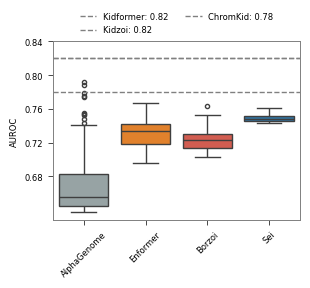

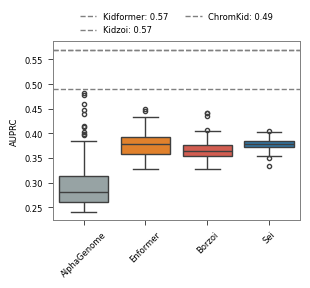

In [109]:
# Setup (keep this part as is)
cell_name = 'PT'
model_order = (
    top_auroc_filtered.groupby("Model")["AUROC"]
    .max()
    .sort_values(ascending=False)
    .index.tolist()
)


colors ={"BorzoiFT": "#4DB5BD",
         "EnformerFT":'#FA8072',
         "ChromeKid": '#5294C2'}


box_colors = {
    'Enformer': '#ff7f0e',
    'Sei': '#1f77b4',
    'Borzoi': '#e74c3c'
}

palette = [box_colors.get(model, '#95a5a6') for model in model_order]

# Create plots

top_auroc_filtered = top_auroc_filtered[
    top_auroc_filtered['Model'] != 'BorzoiFTens']

top_auprc_filtered = top_auprc_filtered[
    top_auprc_filtered['Model'] != 'BorzoiFTens']

plot_boxplot(top_auroc_filtered, "AUROC", top1_auroc, model_order, palette, colors, "./fig2c.pdf",yticks=[0.68, 0.72, 0.76, 0.80, 0.84])
plot_boxplot(top_auprc_filtered, "AUPRC", top1_auprc, model_order, palette, colors, "./fig2d.pdf", 
            yticks=np.arange(0.25, 0.60, 0.05))

# plotting cell_specific auroc-prc cuvres

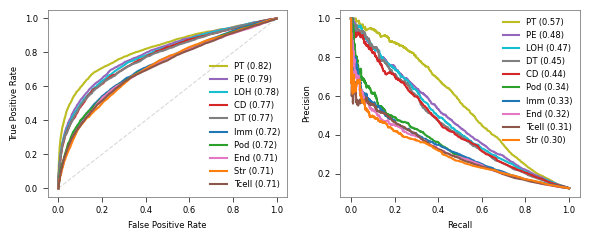

In [106]:
sad_caai, imb_labels, targets_df= compute_caai(models['Kidzoi']['pos'], models['Kidzoi']['neg'], model ='Kidzoi'.lower())
plot_roc_pr_cells(imb_labels, sad_caai, cell_info,suptitle=None, save_pdf=None, filename="./fig3_c_and_d")

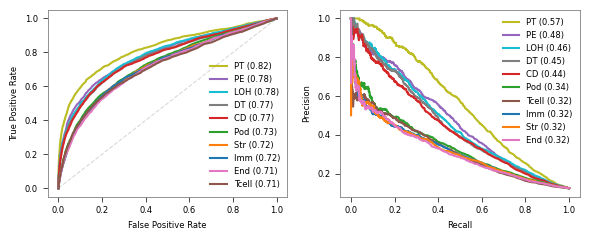

In [108]:
sad_caai, imb_labels, targets_df= compute_caai(models['Kidformer']['pos'], models['Kidformer']['neg'], model ='Kidformer'.lower())
plot_roc_pr_cells(imb_labels, sad_caai, cell_info,suptitle=None, save_pdf=None, filename="./supp_enformer")

Saved figure as ./supp_chromkid


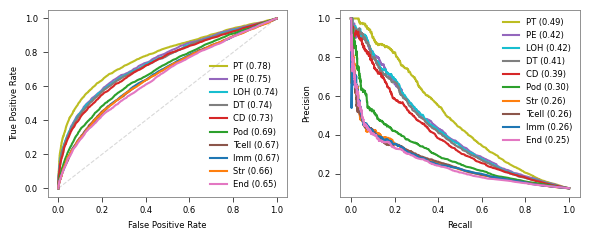

In [107]:
sad_caai, imb_labels, targets_df= compute_caai(models['ChromKid']['pos'], models['ChromKid']['neg'], model ='chromkid'.lower())
plot_roc_pr_cells(imb_labels, sad_caai, cell_info,suptitle=None, save_pdf=True, filename="./supp_chromkid")
